In [22]:
import os
import csv
import ast
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

from utils import savefig

plt.rcParams['font.size'] = 14

In [18]:
def load_data(path, training_data_path, model_num, exp, paramters, training_data_length=200):
    data_single_model = {}
    with open(path/"contiguity_effect.csv", "r") as f:
        reader = csv.reader(f)
        for row in reader:
            data_single_model["model_num"] = model_num
            data_single_model["exp"] = exp

            for key, value in paramters.items():
                data_single_model[key] = value

            data_single_model["accuracy"] = float(row[0])
            data_single_model["forward_asymmetry"] = float(row[1])
            data_single_model["temporal_factor"] = float(row[2])

            classifier_data = pickle.load(open(path/"ridge_classifier_stat.pkl", "rb"))
            data_single_model["index_decoding_accuracy_encoding_phase"] = classifier_data["index_enc_acc"]
            data_single_model["item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc"]
            data_single_model["last_item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc_last"]
            data_single_model["index_decoding_accuracy_recall_phase"] = classifier_data["index_rec_acc"]
            data_single_model["item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc"]
            data_single_model["last_item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc_last"]
            data_single_model["index_decoding_accuracy"] = (data_single_model["index_decoding_accuracy_encoding_phase"] + data_single_model["index_decoding_accuracy_recall_phase"]) / 2
            data_single_model["item_decoding_accuracy"] = (data_single_model["item_decoding_accuracy_encoding_phase"] + data_single_model["item_decoding_accuracy_recall_phase"]) / 2
            data_single_model["last_item_decoding_accuracy"] = (data_single_model["last_item_decoding_accuracy_encoding_phase"] + data_single_model["last_item_decoding_accuracy_recall_phase"]) / 2

            explained_variance_data = np.load(path/"explained_variance.npy")
            data_single_model["explained_variance_encoding_index"] = explained_variance_data[0]
            data_single_model["explained_variance_recall_index"] = explained_variance_data[1]
            data_single_model["explained_variance_index"] = (data_single_model["explained_variance_encoding_index"] + data_single_model["explained_variance_recall_index"]) / 2
            data_single_model["explained_variance_encoding_identity"] = explained_variance_data[2]
            data_single_model["explained_variance_recall_identity"] = explained_variance_data[3]
            data_single_model["explained_variance_identity"] = (data_single_model["explained_variance_encoding_identity"] + data_single_model["explained_variance_recall_identity"]) / 2

            cross_decoding_data = np.load(path/"cross_acc.npy")
            data_single_model["cross_decoding_accuracy_index_rec_enc"] = cross_decoding_data[0]
            data_single_model["cross_decoding_accuracy_identity_rec_enc"] = cross_decoding_data[1]
            data_single_model["cross_decoding_accuracy_index_enc_rec"] = cross_decoding_data[2]
            data_single_model["cross_decoding_accuracy_identity_enc_rec"] = cross_decoding_data[3]
            data_single_model["cross_decoding_accuracy_index"] = (data_single_model["cross_decoding_accuracy_index_rec_enc"] + data_single_model["cross_decoding_accuracy_index_enc_rec"]) / 2
            data_single_model["cross_decoding_accuracy_identity"] = (data_single_model["cross_decoding_accuracy_identity_rec_enc"] + data_single_model["cross_decoding_accuracy_identity_enc_rec"]) / 2

            try:
                training_data = np.load(training_data_path/"accuracy_2.npy")
            except:
                training_data = np.load(training_data_path/"accuracy_1.npy")
            # find the final consecutive zeros in the training data and set it to the last non-zero value
            zero_indices = np.where(training_data == 0)[0]
            if len(zero_indices) > 0:
                last_zero_index = zero_indices[0]
                training_data[last_zero_index:] = training_data[last_zero_index-1]
            if training_data.shape[0] < training_data_length and training_data.shape[0] > 0:
                training_data = np.pad(training_data, (0, training_data_length - training_data.shape[0]), mode='constant', constant_values=training_data[-1])
            data_single_model["training_accuracy"] = training_data

            break
    return data_single_model


In [29]:
data = []

data_folder = Path("./experiments/ExtraObs/EnvCxt/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/ExtraObs/EnvCxt/saved_models/ValueMemoryGRU")

setup_names = ["setup_baseline", "setup_gaussiannoise05", "setup_gaussiannoise1"]
noise_stds = [0.0, 0.5, 1.0]

seq_len = 8

exp = "ctx"

for setup_name, noise_std in zip(setup_names, noise_stds):
    parameters = {
        "noise_std": noise_std,
        "seq_len": seq_len,
    }
    
    training_data_length = 200
    for i in range(10):
        data_path = data_folder / setup_name / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                # perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                # data_single_model["perturbation_accuracy"] = perturbation_data
                # if os.path.exists(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     item_invariance_data = np.load(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["item_invariance_accuracy"] = item_invariance_data
                #     item_invariance_cross_phase_data = np.load(item_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                # else:
                #     data_single_model["item_invariance_accuracy"] = None
                #     data_single_model["item_invariance_cross_phase_accuracy"] = None
                # if os.path.exists(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     time_invariance_data = np.load(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["time_invariance_accuracy"] = time_invariance_data
                #     time_invariance_cross_phase_data = np.load(time_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                # else:
                #     data_single_model["time_invariance_accuracy"] = None
                #     data_single_model["time_invariance_cross_phase_accuracy"] = None
                data.append(data_single_model)

df = pd.DataFrame(data)
print(len(data))

21


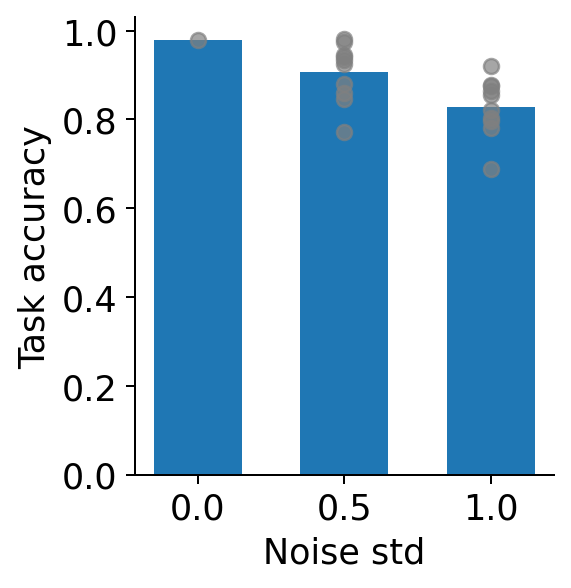

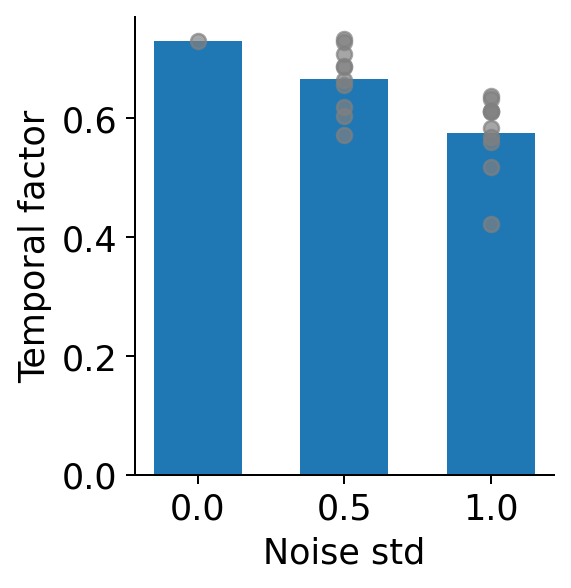

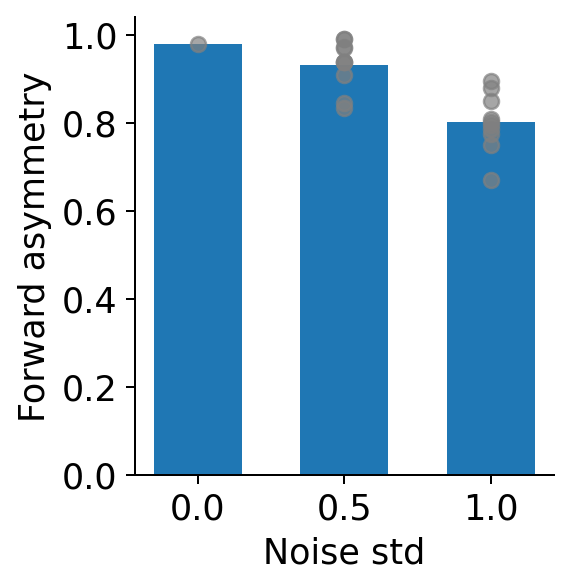

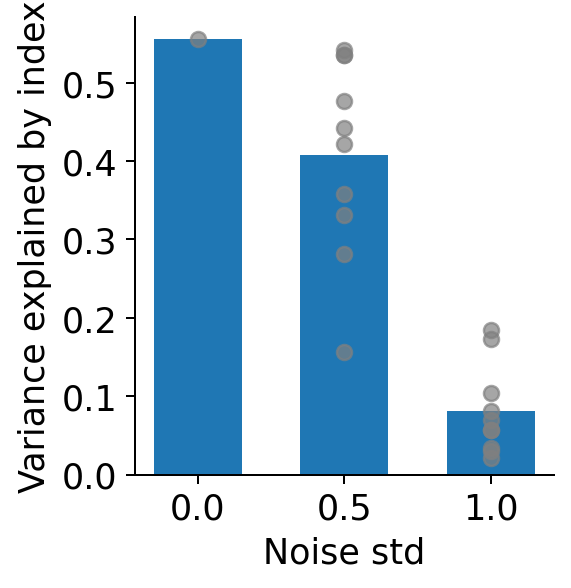

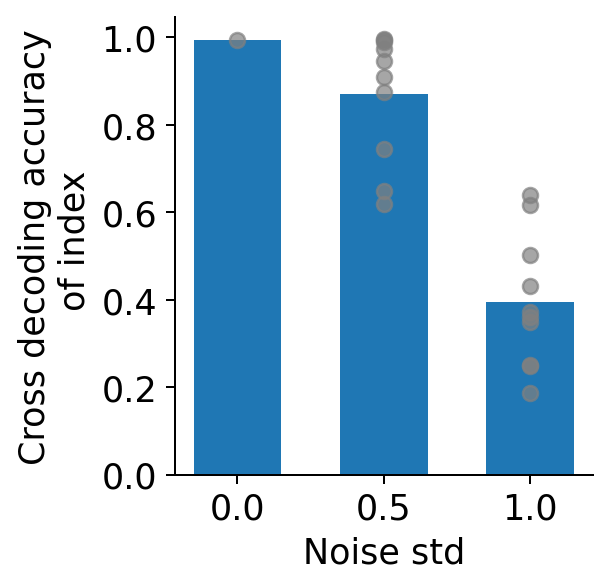

In [24]:
# bar plot of each metric for each noise std

accuracy_mean_by_noise_std = df.groupby("noise_std")["accuracy"].mean()
accuracy_std_by_noise_std = df.groupby("noise_std")["accuracy"].std()

temporal_factor_mean_by_noise_std = df.groupby("noise_std")["temporal_factor"].mean()
temporal_factor_std_by_noise_std = df.groupby("noise_std")["temporal_factor"].std()

forward_asymmetry_mean_by_noise_std = df.groupby("noise_std")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_std = df.groupby("noise_std")["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_std = df.groupby("noise_std")["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_std = df.groupby("noise_std")["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_std = df.groupby("noise_std")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_std = df.groupby("noise_std")["cross_decoding_accuracy_identity"].mean()


def plot_mean_scatter_bar(mean, df, df_label, noise_stds, y_label):
    plt.figure(figsize=(3, 3.3), dpi=180)
    plt.bar(noise_stds, mean, width=0.3)
    plt.scatter(df["noise_std"], df[df_label], color="gray", alpha=0.7)
    plt.xlabel("Noise std")
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

plot_mean_scatter_bar(accuracy_mean_by_noise_std, df, "accuracy", noise_stds, "Task accuracy")
plot_mean_scatter_bar(temporal_factor_mean_by_noise_std, df, "temporal_factor", noise_stds, "Temporal factor")
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_std, df, "forward_asymmetry", noise_stds, "Forward asymmetry")
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_std, df, "explained_variance_index", noise_stds, "Variance explained by index")
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_std, df, "cross_decoding_accuracy_index", noise_stds, "Cross decoding accuracy\n of index")


In [37]:
data_samediff = []

data_folder = Path("./experiments/ExtraObs/RecallCtx/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/ExtraObs/RecallCtx/saved_models/ValueMemoryGRU")

setup_names = ["setup_baseline", "setup_randnoise1_same", "setup_randnoise1_diff"]
noise_types = ["no", "same", "diff"]

seq_len = 8

exp = "ctx"

for setup_name, noise_type in zip(setup_names, noise_types):
    parameters = {
        "noise_type": noise_type,
        "seq_len": seq_len,
    }
    
    training_data_length = 200
    for i in range(10):
        data_path = data_folder / setup_name / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                # perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                # data_single_model["perturbation_accuracy"] = perturbation_data
                # if os.path.exists(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     item_invariance_data = np.load(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["item_invariance_accuracy"] = item_invariance_data
                #     item_invariance_cross_phase_data = np.load(item_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                # else:
                #     data_single_model["item_invariance_accuracy"] = None
                #     data_single_model["item_invariance_cross_phase_accuracy"] = None
                # if os.path.exists(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     time_invariance_data = np.load(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["time_invariance_accuracy"] = time_invariance_data
                #     time_invariance_cross_phase_data = np.load(time_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                # else:
                #     data_single_model["time_invariance_accuracy"] = None
                #     data_single_model["time_invariance_cross_phase_accuracy"] = None
                data_samediff.append(data_single_model)

df_samediff = pd.DataFrame(data_samediff)
print(len(data_samediff))

18


0     same
1     same
2     same
3     same
4     same
5     same
6     same
7     same
8     same
9     diff
10    diff
11    diff
12    diff
13    diff
14    diff
15    diff
16    diff
17    diff
Name: noise_type, dtype: object


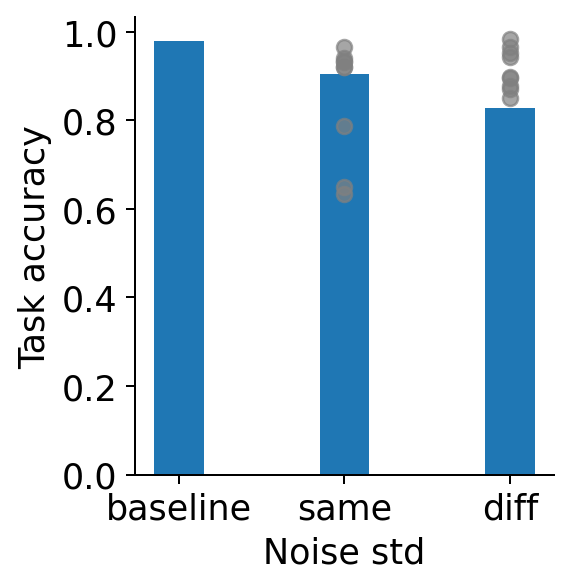

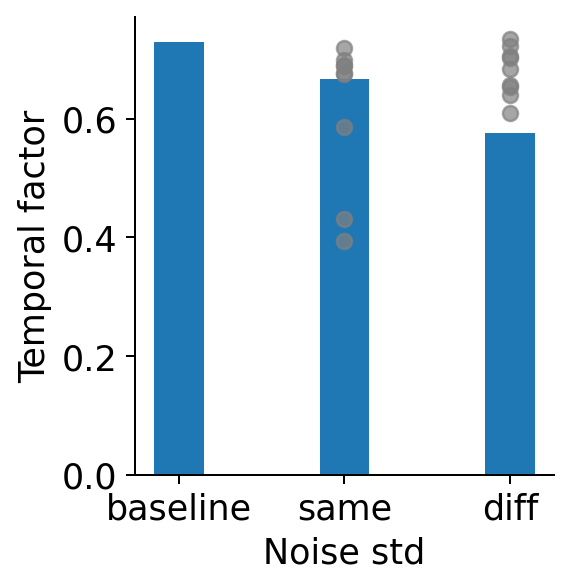

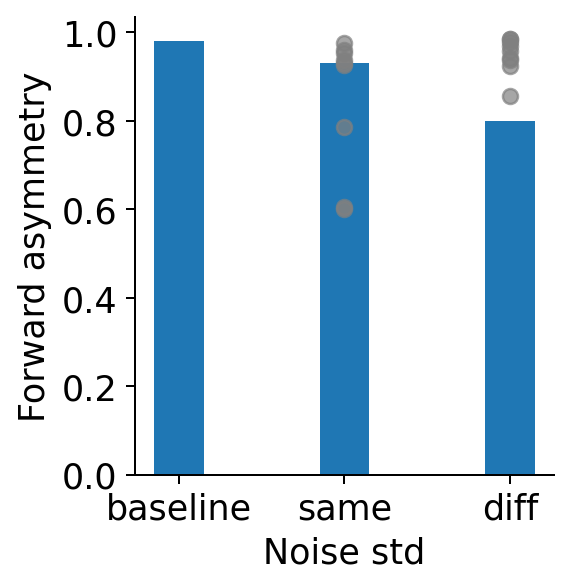

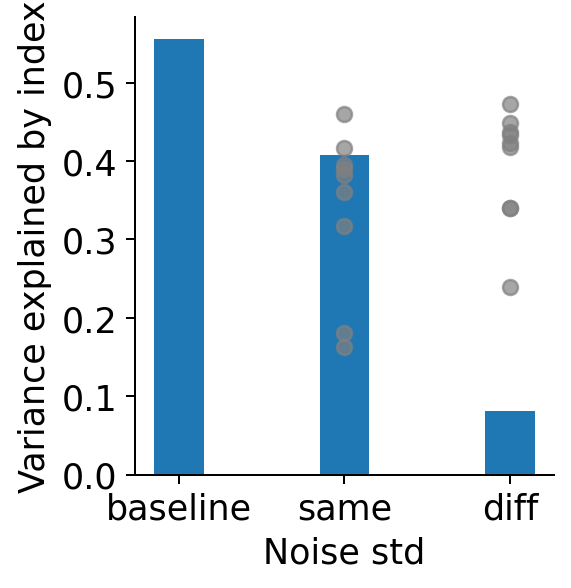

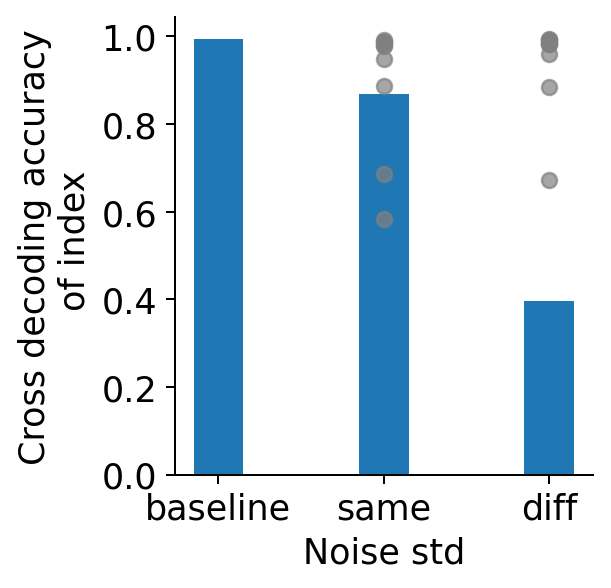

In [39]:
# bar plot of each metric for each noise std

df_samediff["noise_type_int"] = df_samediff["noise_type"].map({"no": 0, "same": 1, "diff": 2})

accuracy_mean_by_noise_type = df_samediff.groupby("noise_type")["accuracy"].mean()
accuracy_std_by_noise_type = df_samediff.groupby("noise_type")["accuracy"].std()

temporal_factor_mean_by_noise_type = df_samediff.groupby("noise_type")["temporal_factor"].mean()
temporal_factor_std_by_noise_type = df_samediff.groupby("noise_type")["temporal_factor"].std()

forward_asymmetry_mean_by_noise_type = df_samediff.groupby("noise_type")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_type = df_samediff.groupby("noise_type")["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_type = df_samediff.groupby("noise_type")["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_type = df_samediff.groupby("noise_type")["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_type = df_samediff.groupby("noise_type")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_type = df_samediff.groupby("noise_type")["cross_decoding_accuracy_identity"].mean()


def plot_mean_scatter_bar(mean, df, df_label, noise_stds, y_label):
    plt.figure(figsize=(3, 3.3), dpi=180)
    plt.bar(np.arange(3), mean, width=0.3)
    plt.scatter(df["noise_type_int"], df[df_label], color="gray", alpha=0.7)
    plt.xticks(np.arange(3), ["baseline", "same", "diff"])
    plt.xlabel("Noise std")
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

print(df_samediff["noise_type"])
plot_mean_scatter_bar(accuracy_mean_by_noise_std, df_samediff, "accuracy", noise_stds, "Task accuracy")
plot_mean_scatter_bar(temporal_factor_mean_by_noise_std, df_samediff, "temporal_factor", noise_stds, "Temporal factor")
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_std, df_samediff, "forward_asymmetry", noise_stds, "Forward asymmetry")
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_std, df_samediff, "explained_variance_index", noise_stds, "Variance explained by index")
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_std, df_samediff, "cross_decoding_accuracy_index", noise_stds, "Cross decoding accuracy\n of index")
